# Individual Exploration: 유저/아이템 개별 시퀀스 탐색

## 목적
- 유저/아이템의 개별 상호작용 패턴 확인
- 세션 정의를 위한 시간 간격 기준 탐색

## 사용법
- index 값을 변경하여 다양한 유저/아이템 탐색
- 기간 조절: start_date, duration_days

---
## 0. 데이터 로드 & 인덱스 매핑

In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/train/'
print("Setup complete.")

Setup complete.


In [2]:
# 데이터 로드
ratings = pd.read_csv(os.path.join(DATA_PATH, 'train_ratings.csv'))
ratings['datetime'] = pd.to_datetime(ratings['time'], unit='s')

# 메타데이터 로드
titles = pd.read_csv(os.path.join(DATA_PATH, 'titles.tsv'), sep='\t')
genres = pd.read_csv(os.path.join(DATA_PATH, 'genres.tsv'), sep='\t')
years = pd.read_csv(os.path.join(DATA_PATH, 'years.tsv'), sep='\t')

# 아이템별 장르 리스트
item_genres = genres.groupby('item')['genre'].apply(list).to_dict()

# 아이템 메타데이터 통합
item_meta = titles.merge(years, on='item', how='left')
item_meta['genres'] = item_meta['item'].map(item_genres)

# 아이템 인기도 계산
item_popularity = ratings['item'].value_counts()
item_meta['popularity'] = item_meta['item'].map(item_popularity)
item_meta['popularity_rank'] = item_meta['popularity'].rank(ascending=False, method='min')

print(f"데이터 로드 완료")
print(f"상호작용: {len(ratings):,}개")
print(f"유저: {ratings['user'].nunique():,}명")
print(f"아이템: {ratings['item'].nunique():,}개")

데이터 로드 완료
상호작용: 5,154,471개
유저: 31,360명
아이템: 6,807개


In [3]:
# 인덱스 ↔ ID 매핑 테이블 생성
unique_users = sorted(ratings['user'].unique())
unique_items = sorted(ratings['item'].unique())

user_id_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
user_idx_to_id = {idx: uid for idx, uid in enumerate(unique_users)}

item_id_to_idx = {iid: idx for idx, iid in enumerate(unique_items)}
item_idx_to_id = {idx: iid for idx, iid in enumerate(unique_items)}

print(f"유저 인덱스 범위: 0 ~ {len(unique_users)-1}")
print(f"아이템 인덱스 범위: 0 ~ {len(unique_items)-1}")

# 데이터 기간
DATA_START = ratings['datetime'].min()
DATA_END = ratings['datetime'].max()
print(f"\n데이터 기간: {DATA_START.date()} ~ {DATA_END.date()}")

유저 인덱스 범위: 0 ~ 31359
아이템 인덱스 범위: 0 ~ 6806

데이터 기간: 2005-04-11 ~ 2015-03-31


In [4]:
# 유저별 데이터 미리 정렬 (시간순)
ratings_sorted = ratings.sort_values(['user', 'time']).reset_index(drop=True)
ratings_sorted['seq_num'] = ratings_sorted.groupby('user').cumcount() + 1
ratings_sorted['time_diff'] = ratings_sorted.groupby('user')['time'].diff()

print("데이터 전처리 완료")

데이터 전처리 완료


---
## 1. 유저 시퀀스 탐색

### 1-1. 유저 시퀀스 시각화

In [5]:
def plot_user_sequence(user_index, start_date=None, duration_days=None, session_gap_hours=1):
    """
    유저의 상호작용 시퀀스를 시간축 위에 시각화
    
    Parameters:
    - user_index: 유저 인덱스 (0부터 시작)
    - start_date: 시작일 (None이면 데이터 시작일)
    - duration_days: 볼 기간 (None이면 전체 기간)
    - session_gap_hours: 세션 구분 기준 (시간 단위)
    """
    # 유저 ID 변환
    user_id = user_idx_to_id[user_index]
    user_data = ratings_sorted[ratings_sorted['user'] == user_id].copy()
    
    if len(user_data) == 0:
        print(f"유저 {user_index} (ID: {user_id})의 데이터가 없습니다.")
        return
    
    # 기간 필터링
    if start_date is None:
        start_date = DATA_START
    else:
        start_date = pd.to_datetime(start_date)
    
    if duration_days is None:
        end_date = DATA_END
    else:
        end_date = start_date + timedelta(days=duration_days)
    
    # 세션 구분
    session_gap_seconds = session_gap_hours * 3600
    user_data['new_session'] = (user_data['time_diff'] > session_gap_seconds) | (user_data['time_diff'].isna())
    user_data['session_id'] = user_data['new_session'].cumsum()
    
    # 기간 내 데이터만
    mask = (user_data['datetime'] >= start_date) & (user_data['datetime'] <= end_date)
    plot_data = user_data[mask]
    
    if len(plot_data) == 0:
        print(f"선택한 기간 내 데이터가 없습니다.")
        return
    
    # 시각화
    fig, ax = plt.subplots(figsize=(16, 3))
    
    # 세션별로 다른 색상
    sessions = plot_data['session_id'].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, min(len(sessions), 10)))
    
    for i, session in enumerate(sessions):
        session_data = plot_data[plot_data['session_id'] == session]
        color = colors[i % 10]
        ax.scatter(session_data['datetime'], [1]*len(session_data), 
                   c=[color], s=50, alpha=0.7, label=f'Session {session}' if i < 10 else '')
    
    ax.set_xlim(start_date, end_date)
    ax.set_ylim(0.5, 1.5)
    ax.set_yticks([])
    ax.set_xlabel('Date')
    ax.set_title(f'User {user_index} (ID: {user_id}) - {len(plot_data)} interactions, {len(sessions)} sessions (gap threshold: {session_gap_hours}h)')
    
    # x축 포맷
    if duration_days and duration_days <= 7:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    elif duration_days and duration_days <= 90:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    else:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 요약 통계
    print(f"\n[유저 {user_index} 요약]")
    print(f"전체 상호작용 수: {len(user_data)}")
    print(f"표시 기간 내 상호작용 수: {len(plot_data)}")
    print(f"세션 수 (gap={session_gap_hours}h): {len(sessions)}")
    print(f"첫 상호작용: {user_data['datetime'].min()}")
    print(f"마지막 상호작용: {user_data['datetime'].max()}")
    print(f"활동 기간: {(user_data['datetime'].max() - user_data['datetime'].min()).days}일")

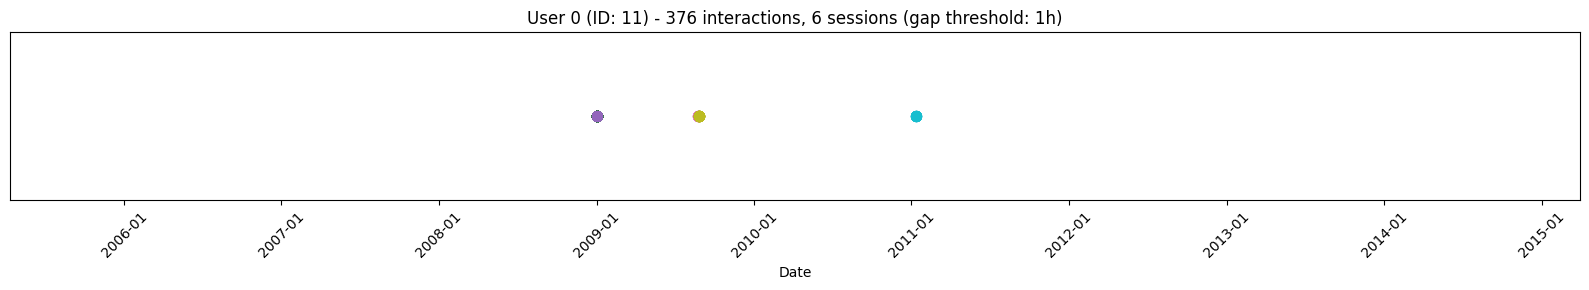


[유저 0 요약]
전체 상호작용 수: 376
표시 기간 내 상호작용 수: 376
세션 수 (gap=1h): 6
첫 상호작용: 2009-01-01 04:02:09
마지막 상호작용: 2011-01-12 01:35:59
활동 기간: 740일


In [6]:
# === 여기서 값을 변경하여 탐색 ===
USER_INDEX = 0  # 유저 인덱스 (0 ~ 31359)
START_DATE = '2006-10-10 06:41:32'  # 시작일 (예: '2010-01-01') 또는 None (전체)
DURATION_DAYS = 1  # 볼 기간 (예: 30, 365) 또는 None (전체)
SESSION_GAP_HOURS = 1  # 세션 구분 기준 (시간)
START_DATE = None
DURATION_DAYS = None

plot_user_sequence(USER_INDEX, START_DATE, DURATION_DAYS, SESSION_GAP_HOURS)

In [7]:
# 짧은 기간 상세 확인 예시
# plot_user_sequence(USER_INDEX, start_date='2010-01-01', duration_days=7, session_gap_hours=0.5)

### 1-2. 유저 시퀀스 상세 테이블

In [8]:
def show_user_sequence_table(user_index, start_seq=1, end_seq=30):
    """
    유저의 상호작용 시퀀스를 테이블로 출력
    
    Parameters:
    - user_index: 유저 인덱스
    - start_seq: 시작 시퀀스 번호
    - end_seq: 종료 시퀀스 번호
    """
    user_id = user_idx_to_id[user_index]
    user_data = ratings_sorted[ratings_sorted['user'] == user_id].copy()
    
    if len(user_data) == 0:
        print(f"유저 {user_index}의 데이터가 없습니다.")
        return
    
    # 시퀀스 범위 필터
    mask = (user_data['seq_num'] >= start_seq) & (user_data['seq_num'] <= end_seq)
    display_data = user_data[mask].copy()
    
    # 아이템 메타데이터 추가
    display_data = display_data.merge(item_meta[['item', 'title', 'year', 'genres', 'popularity_rank']], 
                                       on='item', how='left')
    
    # time_diff를 읽기 쉽게 변환
    def format_time_diff(seconds):
        if pd.isna(seconds):
            return '-'
        elif seconds < 60:
            return f"{seconds:.0f}초"
        elif seconds < 3600:
            return f"{seconds/60:.1f}분"
        elif seconds < 86400:
            return f"{seconds/3600:.1f}시간"
        else:
            return f"{seconds/86400:.1f}일"
    
    display_data['time_diff_str'] = display_data['time_diff'].apply(format_time_diff)
    
    # 출력할 컬럼 선택
    output_cols = ['seq_num', 'datetime', 'time_diff_str', 'item', 'title', 'year', 'genres', 'popularity_rank']
    output_data = display_data[output_cols].copy()
    output_data.columns = ['Seq', 'DateTime', 'Gap', 'ItemID', 'Title', 'Year', 'Genres', 'PopRank']
    
    print(f"[유저 {user_index} (ID: {user_id}) 시퀀스 {start_seq}~{end_seq}]")
    print(f"전체 시퀀스 길이: {len(user_data)}\n")
    
    # pandas 출력 설정
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 
                           'display.width', None, 'display.max_colwidth', 30):
        print(output_data.to_string(index=False))
    
    return output_data

In [9]:
# === 여기서 값을 변경하여 탐색 ===
USER_INDEX = 0
START_SEQ = 1  # 시작 시퀀스 번호
END_SEQ = 20   # 종료 시퀀스 번호

_ = show_user_sequence_table(USER_INDEX, START_SEQ, END_SEQ)

[유저 0 (ID: 11) 시퀀스 1~20]
전체 시퀀스 길이: 376

 Seq            DateTime  Gap  ItemID                                     Title   Year                                       Genres  PopRank
   1 2009-01-01 04:02:09    -    4643                 Planet of the Apes (2001) 2001.0           [Action, Adventure, Drama, Sci-Fi]   1056.0
   2 2009-01-01 04:02:14   5초     170                            Hackers (1995) 1995.0         [Action, Adventure, Crime, Thriller]   1066.0
   3 2009-01-01 04:02:19   5초     531                 Secret Garden, The (1993) 1993.0                            [Children, Drama]   1209.0
   4 2009-01-01 04:02:22   3초     616                    Aristocats, The (1970) 1970.0                        [Animation, Children]   1074.0
   5 2009-01-01 04:02:43  21초    2140                  Dark Crystal, The (1982) 1982.0                         [Adventure, Fantasy]    824.0
   6 2009-01-01 04:03:03  20초    2722                      Deep Blue Sea (1999) 1999.0           [Action, Horror,

### 1-3. 유저 세션 분석

In [10]:
def analyze_user_sessions(user_index, session_gap_hours=1):
    """
    유저의 세션 분석
    
    Parameters:
    - user_index: 유저 인덱스
    - session_gap_hours: 세션 구분 기준 (시간)
    """
    user_id = user_idx_to_id[user_index]
    user_data = ratings_sorted[ratings_sorted['user'] == user_id].copy()
    
    if len(user_data) == 0:
        print(f"유저 {user_index}의 데이터가 없습니다.")
        return
    
    # 세션 구분
    session_gap_seconds = session_gap_hours * 3600
    user_data['new_session'] = (user_data['time_diff'] > session_gap_seconds) | (user_data['time_diff'].isna())
    user_data['session_id'] = user_data['new_session'].cumsum()
    
    # 세션별 통계
    session_stats = user_data.groupby('session_id').agg(
        interactions=('item', 'count'),
        start_time=('datetime', 'min'),
        end_time=('datetime', 'max')
    )
    session_stats['duration_minutes'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds() / 60
    
    print(f"[유저 {user_index} (ID: {user_id}) 세션 분석]")
    print(f"세션 구분 기준: {session_gap_hours}시간")
    print(f"\n총 상호작용 수: {len(user_data)}")
    print(f"총 세션 수: {len(session_stats)}")
    print(f"\n[세션별 상호작용 수]")
    print(f"  평균: {session_stats['interactions'].mean():.1f}")
    print(f"  중앙값: {session_stats['interactions'].median():.0f}")
    print(f"  최소: {session_stats['interactions'].min()}")
    print(f"  최대: {session_stats['interactions'].max()}")
    print(f"\n[세션 길이 (분)]")
    print(f"  평균: {session_stats['duration_minutes'].mean():.1f}분")
    print(f"  중앙값: {session_stats['duration_minutes'].median():.1f}분")
    
    # 세션 크기 분포
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].hist(session_stats['interactions'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Interactions per session')
    axes[0].set_ylabel('Number of sessions')
    axes[0].set_title(f'Session Size Distribution (User {user_index})')
    axes[0].axvline(15, color='red', linestyle='--', alpha=0.7, label='15 (bootstrap threshold)')
    axes[0].legend()
    
    axes[1].hist(session_stats['duration_minutes'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Session duration (minutes)')
    axes[1].set_ylabel('Number of sessions')
    axes[1].set_title(f'Session Duration Distribution (User {user_index})')
    
    plt.tight_layout()
    plt.show()
    
    # 상위 10개 세션 출력
    print(f"\n[상위 10개 세션 (상호작용 수 기준)]")
    top_sessions = session_stats.nlargest(10, 'interactions')[['interactions', 'start_time', 'duration_minutes']]
    top_sessions['duration_minutes'] = top_sessions['duration_minutes'].round(1)
    print(top_sessions.to_string())
    
    return session_stats

[유저 0 (ID: 11) 세션 분석]
세션 구분 기준: 1시간

총 상호작용 수: 376
총 세션 수: 6

[세션별 상호작용 수]
  평균: 62.7
  중앙값: 24
  최소: 10
  최대: 198

[세션 길이 (분)]
  평균: 53.1분
  중앙값: 22.2분


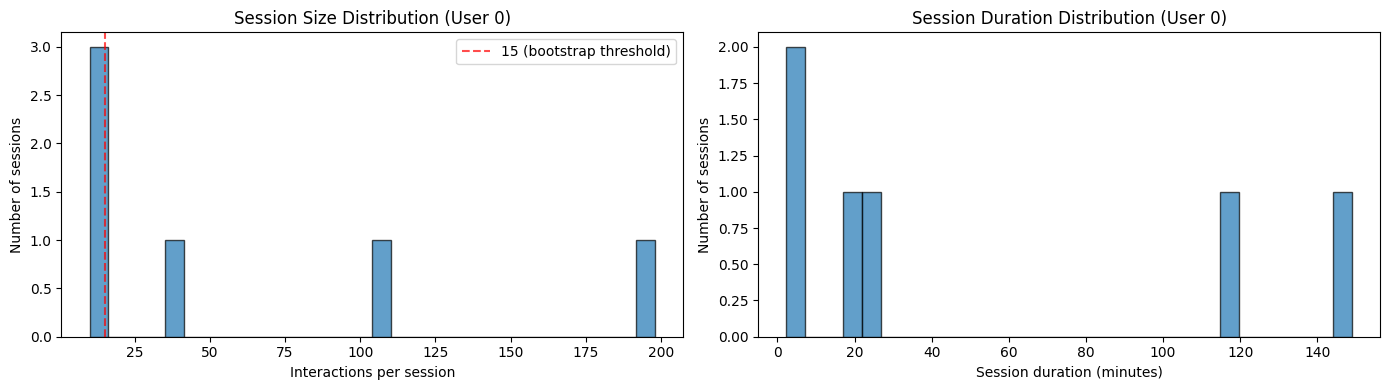


[상위 10개 세션 (상호작용 수 기준)]
            interactions          start_time  duration_minutes
session_id                                                    
1                    198 2009-01-01 04:02:09             117.3
2                    106 2009-01-01 22:56:11             148.9
5                     36 2009-08-25 03:05:51              22.8
4                     13 2009-08-24 19:42:07              21.5
6                     13 2011-01-12 01:30:11               5.8
3                     10 2009-01-02 18:15:39               2.3


In [11]:
# === 여기서 값을 변경하여 탐색 ===
USER_INDEX = 0
SESSION_GAP_HOURS = 1  # 세션 구분 기준

_ = analyze_user_sessions(USER_INDEX, SESSION_GAP_HOURS)

---
## 2. 아이템 시퀀스 탐색

### 2-1. 아이템 시퀀스 시각화

In [12]:
def plot_item_sequence(item_index, start_date=None, duration_days=None, agg='daily'):
    """
    아이템의 상호작용 시퀀스를 시간축 위에 시각화
    
    Parameters:
    - item_index: 아이템 인덱스
    - start_date: 시작일
    - duration_days: 볼 기간
    - agg: 집계 방식 ('daily', 'weekly', 'individual')
    """
    item_id = item_idx_to_id[item_index]
    item_data = ratings[ratings['item'] == item_id].copy()
    
    if len(item_data) == 0:
        print(f"아이템 {item_index}의 데이터가 없습니다.")
        return
    
    # 기간 필터링
    if start_date is None:
        start_date = DATA_START
    else:
        start_date = pd.to_datetime(start_date)
    
    if duration_days is None:
        end_date = DATA_END
    else:
        end_date = start_date + timedelta(days=duration_days)
    
    mask = (item_data['datetime'] >= start_date) & (item_data['datetime'] <= end_date)
    plot_data = item_data[mask]
    
    # 메타데이터
    meta = item_meta[item_meta['item'] == item_id].iloc[0] if item_id in item_meta['item'].values else None
    title = meta['title'] if meta is not None else 'Unknown'
    release_year = meta['year'] if meta is not None and pd.notna(meta['year']) else None
    
    # 시각화
    fig, ax = plt.subplots(figsize=(16, 4))
    
    if agg == 'individual':
        ax.scatter(plot_data['datetime'], [1]*len(plot_data), s=20, alpha=0.5)
        ax.set_ylim(0.5, 1.5)
        ax.set_yticks([])
    elif agg == 'daily':
        daily = plot_data.set_index('datetime').resample('D').size()
        ax.bar(daily.index, daily.values, width=1, alpha=0.7)
        ax.set_ylabel('Daily interactions')
    elif agg == 'weekly':
        weekly = plot_data.set_index('datetime').resample('W').size()
        ax.bar(weekly.index, weekly.values, width=7, alpha=0.7)
        ax.set_ylabel('Weekly interactions')
    
    # 개봉연도 표시
    if release_year and pd.notna(release_year):
        release_date = pd.Timestamp(f"{int(release_year)}-01-01")
        if start_date <= release_date <= end_date:
            ax.axvline(release_date, color='red', linestyle='--', alpha=0.7, label=f'Release: {int(release_year)}')
            ax.legend()
    
    ax.set_xlim(start_date, end_date)
    ax.set_xlabel('Date')
    ax.set_title(f'Item {item_index} (ID: {item_id}): {title} - {len(plot_data)} interactions')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 요약
    print(f"\n[아이템 {item_index} 요약]")
    print(f"제목: {title}")
    print(f"개봉연도: {release_year}")
    print(f"전체 상호작용 수: {len(item_data)}")
    print(f"표시 기간 내 상호작용 수: {len(plot_data)}")
    print(f"첫 상호작용: {item_data['datetime'].min()}")
    print(f"마지막 상호작용: {item_data['datetime'].max()}")

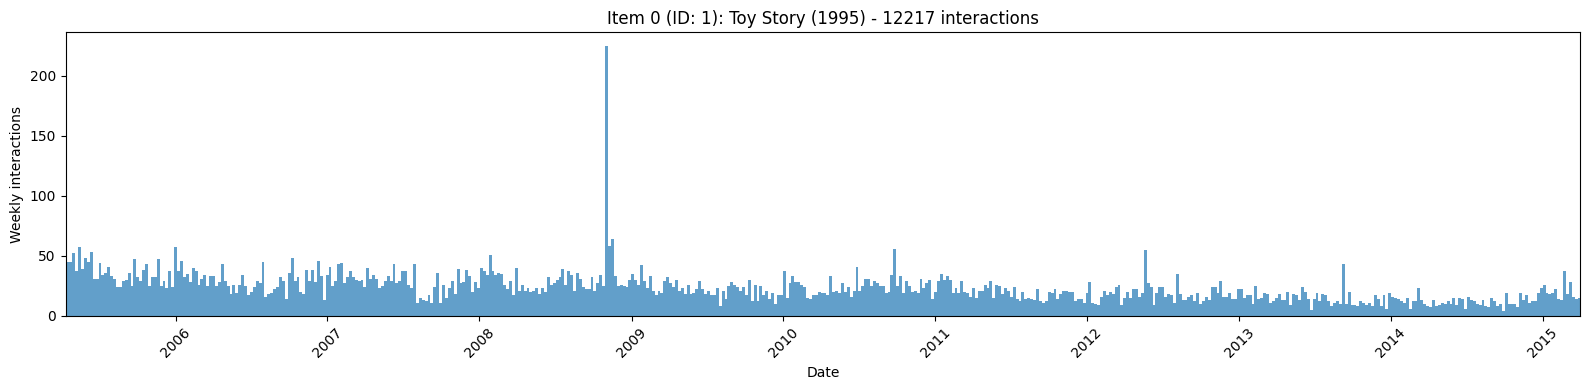


[아이템 0 요약]
제목: Toy Story (1995)
개봉연도: 1995.0
전체 상호작용 수: 12217
표시 기간 내 상호작용 수: 12217
첫 상호작용: 2005-04-11 12:41:27
마지막 상호작용: 2015-03-30 19:57:57


In [13]:
# === 여기서 값을 변경하여 탐색 ===
ITEM_INDEX = 0  # 아이템 인덱스 (0 ~ 6806)
START_DATE = None
DURATION_DAYS = None
AGG = 'weekly'  # 'individual', 'daily', 'weekly'

plot_item_sequence(ITEM_INDEX, START_DATE, DURATION_DAYS, AGG)

### 2-2. 아이템 메타데이터 + 요약 통계

In [14]:
def show_item_info(item_index):
    """
    아이템의 메타데이터와 요약 통계 출력
    """
    item_id = item_idx_to_id[item_index]
    item_data = ratings[ratings['item'] == item_id]
    
    # 메타데이터
    meta = item_meta[item_meta['item'] == item_id]
    
    print(f"[아이템 {item_index} (ID: {item_id}) 정보]")
    print("=" * 50)
    
    if len(meta) > 0:
        m = meta.iloc[0]
        print(f"제목: {m['title']}")
        print(f"개봉연도: {m['year']}")
        print(f"장르: {m['genres']}")
        print(f"인기도 순위: {int(m['popularity_rank'])} / {len(item_meta)}")
    else:
        print("메타데이터 없음")
    
    print(f"\n[상호작용 통계]")
    print(f"총 상호작용 수: {len(item_data):,}")
    print(f"시청한 유저 수: {item_data['user'].nunique():,}")
    print(f"첫 상호작용: {item_data['datetime'].min()}")
    print(f"마지막 상호작용: {item_data['datetime'].max()}")
    print(f"활성 기간: {(item_data['datetime'].max() - item_data['datetime'].min()).days}일")

In [15]:
# === 여기서 값을 변경하여 탐색 ===
ITEM_INDEX = 0

show_item_info(ITEM_INDEX)

[아이템 0 (ID: 1) 정보]
제목: Toy Story (1995)
개봉연도: 1995.0
장르: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']
인기도 순위: 31 / 6807

[상호작용 통계]
총 상호작용 수: 12,217
시청한 유저 수: 12,217
첫 상호작용: 2005-04-11 12:41:27
마지막 상호작용: 2015-03-30 19:57:57
활성 기간: 3640일


---
## 3. 세션 기준 탐색 (여러 유저 샘플링)

In [16]:
def explore_session_thresholds(n_users=100, gap_thresholds=[0.5, 1, 2, 4, 8, 24]):
    """
    다양한 세션 gap threshold에 따른 세션 수 변화 탐색
    
    Parameters:
    - n_users: 샘플링할 유저 수
    - gap_thresholds: 테스트할 gap threshold 리스트 (시간 단위)
    """
    # 유저 샘플링
    sample_users = np.random.choice(unique_users, min(n_users, len(unique_users)), replace=False)
    
    results = []
    
    for gap_hours in gap_thresholds:
        gap_seconds = gap_hours * 3600
        session_counts = []
        interactions_per_session = []
        
        for user_id in sample_users:
            user_data = ratings_sorted[ratings_sorted['user'] == user_id].copy()
            if len(user_data) == 0:
                continue
            
            # 세션 구분
            new_session = (user_data['time_diff'] > gap_seconds) | (user_data['time_diff'].isna())
            n_sessions = new_session.sum()
            session_counts.append(n_sessions)
            interactions_per_session.append(len(user_data) / n_sessions)
        
        results.append({
            'gap_hours': gap_hours,
            'avg_sessions': np.mean(session_counts),
            'median_sessions': np.median(session_counts),
            'avg_interactions_per_session': np.mean(interactions_per_session),
            'median_interactions_per_session': np.median(interactions_per_session)
        })
    
    results_df = pd.DataFrame(results)
    
    print(f"[세션 기준 탐색 결과] (n_users={n_users})")
    print("=" * 70)
    print(results_df.to_string(index=False))
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(results_df['gap_hours'], results_df['avg_sessions'], 'o-', label='Mean')
    axes[0].plot(results_df['gap_hours'], results_df['median_sessions'], 's--', label='Median')
    axes[0].set_xlabel('Session Gap Threshold (hours)')
    axes[0].set_ylabel('Number of Sessions per User')
    axes[0].set_title('Sessions vs Gap Threshold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(results_df['gap_hours'], results_df['avg_interactions_per_session'], 'o-', label='Mean')
    axes[1].plot(results_df['gap_hours'], results_df['median_interactions_per_session'], 's--', label='Median')
    axes[1].axhline(15, color='red', linestyle='--', alpha=0.7, label='15 (bootstrap)')
    axes[1].set_xlabel('Session Gap Threshold (hours)')
    axes[1].set_ylabel('Interactions per Session')
    axes[1].set_title('Interactions per Session vs Gap Threshold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results_df

[세션 기준 탐색 결과] (n_users=500)
 gap_hours  avg_sessions  median_sessions  avg_interactions_per_session  median_interactions_per_session
      0.25        18.828              4.0                     40.374390                        27.281818
      0.50        17.898              4.0                     42.973538                        30.050000
      1.00        17.394              3.0                     45.664736                        33.000000
      2.00        16.908              3.0                     48.172326                        34.000000
      4.00        16.244              3.0                     49.592426                        35.500000
      8.00        15.664              3.0                     51.421657                        39.035714
     12.00        15.270              3.0                     53.592954                        41.781250
     24.00        13.788              3.0                     58.645406                        47.291667
     48.00        12.128   

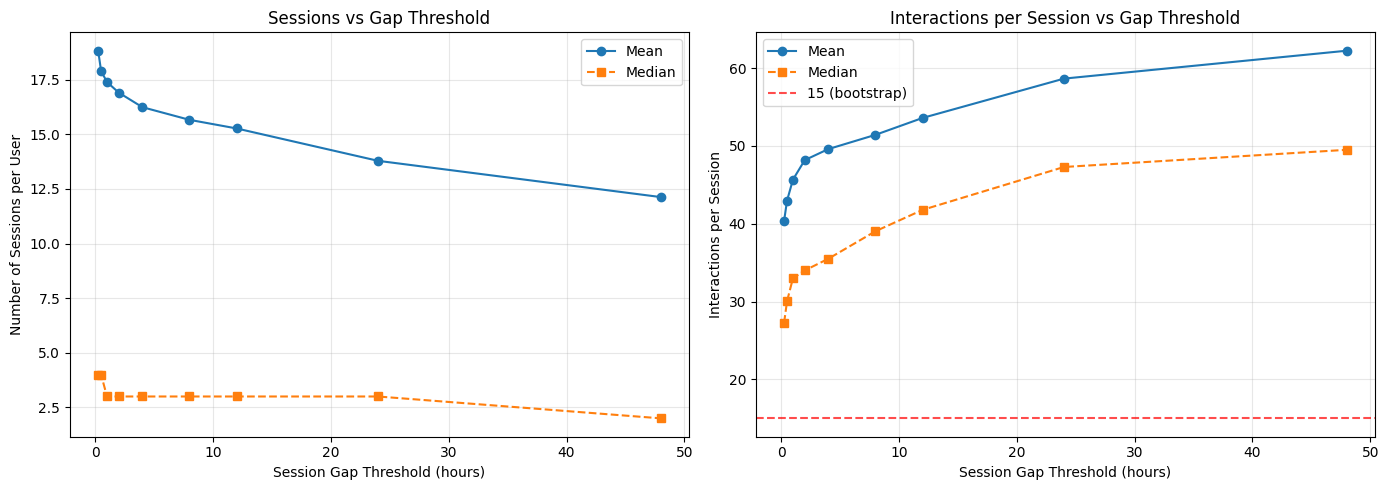

In [17]:
# === 여기서 값을 변경하여 탐색 ===
N_USERS = 500  # 샘플링할 유저 수
GAP_THRESHOLDS = [0.25, 0.5, 1, 2, 4, 8, 12, 24, 48]  # 테스트할 gap (시간)

_ = explore_session_thresholds(N_USERS, GAP_THRESHOLDS)

---
## 4. 빠른 조회 함수들

In [18]:
# ID ↔ Index 변환
def user_id_to_index(user_id):
    return user_id_to_idx.get(user_id, None)

def user_index_to_id(user_index):
    return user_idx_to_id.get(user_index, None)

def item_id_to_index(item_id):
    return item_id_to_idx.get(item_id, None)

def item_index_to_id(item_index):
    return item_idx_to_id.get(item_index, None)

# 아이템 제목으로 검색
def search_item_by_title(keyword):
    matches = item_meta[item_meta['title'].str.contains(keyword, case=False, na=False)]
    if len(matches) == 0:
        print(f"'{keyword}'를 포함하는 아이템이 없습니다.")
        return None
    
    matches = matches.copy()
    matches['index'] = matches['item'].map(item_id_to_idx)
    print(f"'{keyword}' 검색 결과: {len(matches)}개")
    return matches[['index', 'item', 'title', 'year', 'popularity_rank']].head(20)

In [19]:
# 사용 예시
search_item_by_title('Matrix')

'Matrix' 검색 결과: 4개


,index,item,title,year,popularity_rank
1,1435,2571,"Matrix, The (1999)",1999.0,1.0
2920,3193,6365,"Matrix Reloaded, The (2003)",2003.0,155.0
3421,3420,6934,"Matrix Revolutions, The (2003)",2003.0,252.0
3447,4399,27660,"Animatrix, The (2003)",2003.0,655.0


In [20]:
# 인기도 상위 N개 아이템
def get_top_items(n=20):
    top = item_meta.nsmallest(n, 'popularity_rank')[['item', 'title', 'year', 'popularity', 'popularity_rank']].copy()
    top['index'] = top['item'].map(item_id_to_idx)
    return top[['index', 'item', 'title', 'year', 'popularity', 'popularity_rank']]

get_top_items(20)

,index,item,title,year,popularity,popularity_rank
1,1435,2571,"Matrix, The (1999)",1999.0,19699,1.0
2,1642,2959,Fight Club (1999),1999.0,18437,2.0
3,179,296,Pulp Fiction (1994),1994.0,18202,3.0
0,193,318,"Shawshank Redemption, The (1994)",1994.0,18168,4.0
4,220,356,Forrest Gump (1994),1994.0,17339,5.0
5,2670,4993,"Lord of the Rings: The Fellowship of the Ring,...",2001.0,17237,6.0
6,3567,7153,"Lord of the Rings: The Return of the King, The...",2003.0,16656,7.0
7,3038,5952,"Lord of the Rings: The Two Towers, The (2002)",2002.0,16387,8.0
8,356,593,"Silence of the Lambs, The (1991)",1991.0,15847,9.0
9,1580,2858,American Beauty (1999),1999.0,15213,10.0


In [21]:
# 특정 유저의 총 상호작용 수로 유저 찾기
def find_users_by_interaction_count(min_count, max_count):
    user_counts = ratings.groupby('user').size()
    mask = (user_counts >= min_count) & (user_counts <= max_count)
    matched_users = user_counts[mask]
    
    result = pd.DataFrame({
        'user_id': matched_users.index,
        'interactions': matched_users.values
    })
    result['user_index'] = result['user_id'].map(user_id_to_idx)
    
    print(f"상호작용 수 {min_count}~{max_count}: {len(result)}명")
    return result[['user_index', 'user_id', 'interactions']].head(20)

# 예: 정확히 최소 상호작용 수(16개)를 가진 유저 찾기
find_users_by_interaction_count(16,20)

상호작용 수 16~20: 2명


,user_index,user_id,interactions
0,12135,53188,16
1,15643,68606,19
